In [1]:
from utils.inspect_data_helpers import *
from hierarchies.hierarchies import get_hierarchy_tree
import json
import os

In [ ]:
# TODO:
# Set range for epochs e.g [2,12] for whole analysis onwards
# More hierarchical error analysis e.g. what happens to the rest of the prediction if theres an error on level 0

In [14]:

exp_dir = "outputs/ar_hierarchy_masked"
config_path = exp_dir+"/config.json"
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)


hiearchy_tree = get_hierarchy_tree(config["dataset"])
hierarchy_index_dict = hiearchy_tree.get_level_idx_to_class()
metrics, preds = load_experiment(exp_dir)

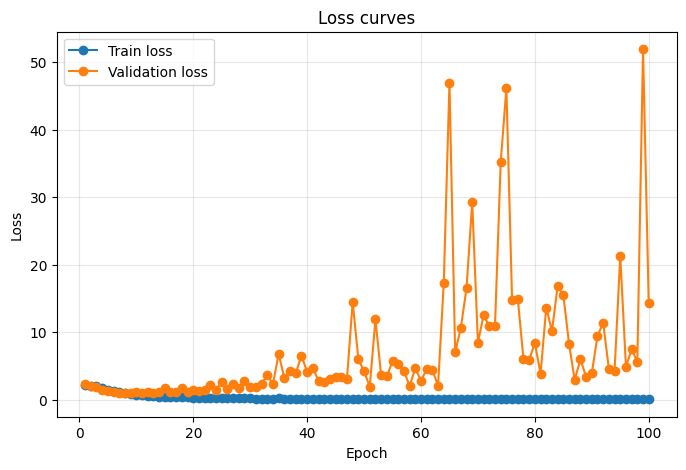

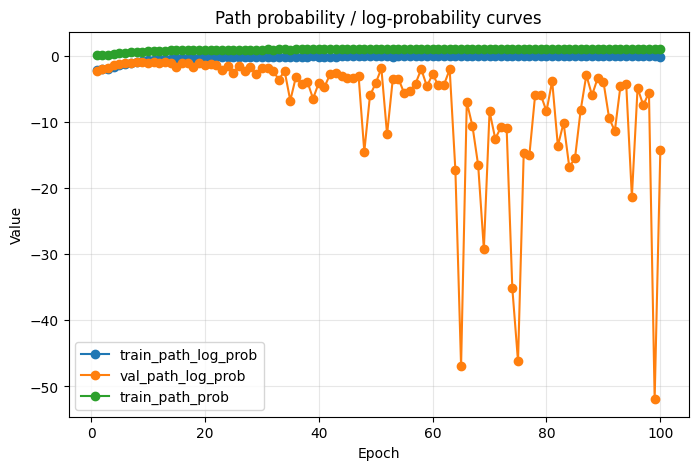

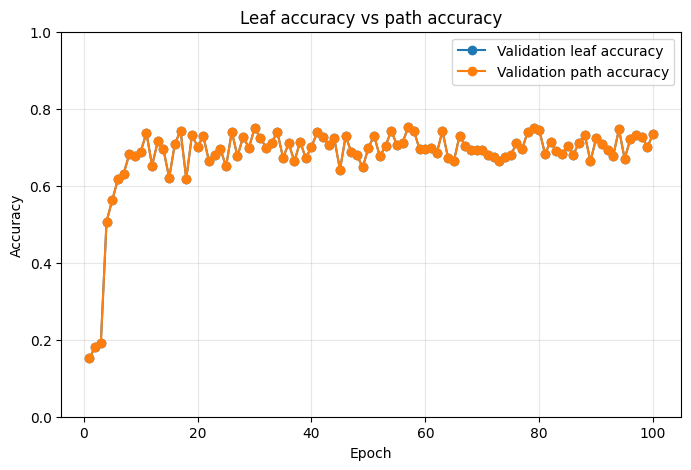

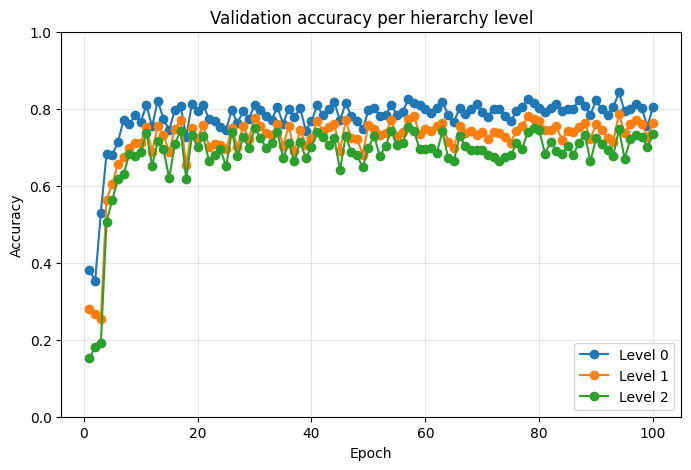

In [10]:
plot_training_dynamics(metrics)

best epoch: 57


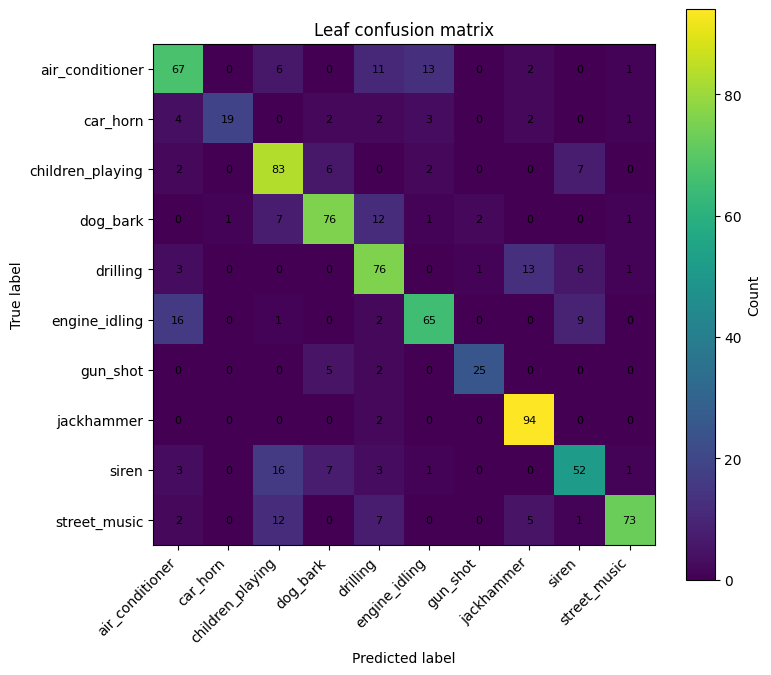


Leaf confusion matrix metrics
-----------------------------
Accuracy:          0.7527
Macro precision:   0.7843
Macro recall:      0.7412
Macro specificity: 0.9721
Macro F1-score:    0.7540


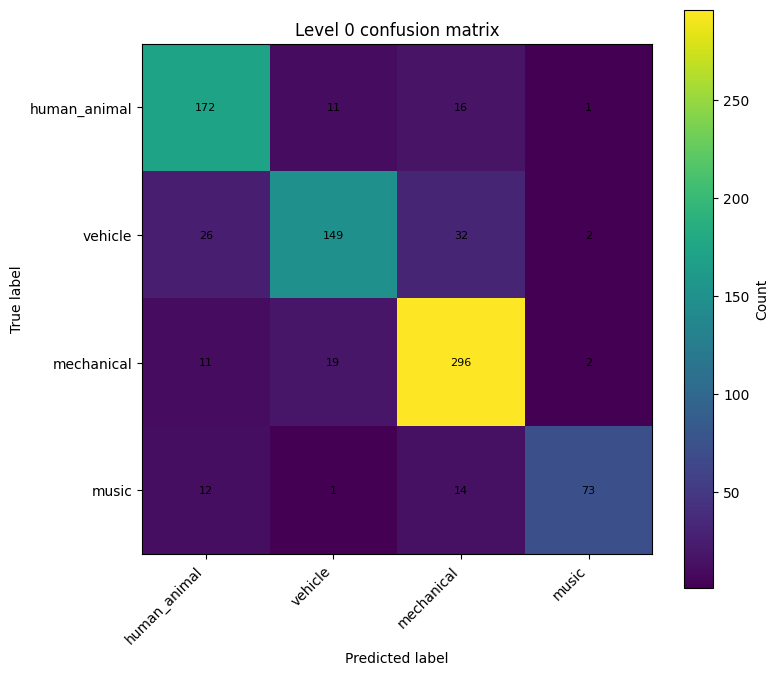


Level 0 confusion matrix metrics
--------------------------------
Accuracy:          0.8244
Macro precision:   0.8422
Macro recall:      0.8013
Macro specificity: 0.9363
Macro F1-score:    0.8166


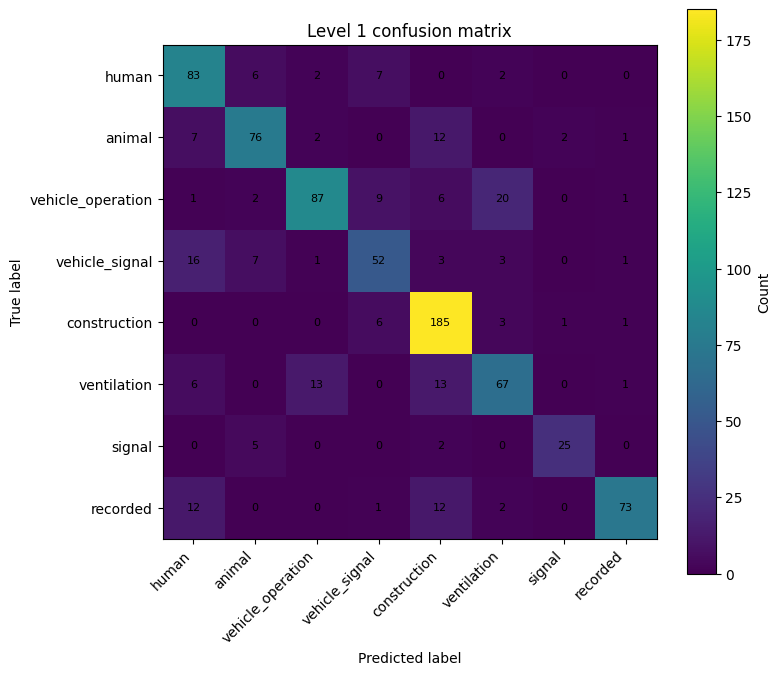


Level 1 confusion matrix metrics
--------------------------------
Accuracy:          0.7742
Macro precision:   0.7864
Macro recall:      0.7540
Macro specificity: 0.9667
Macro F1-score:    0.7651


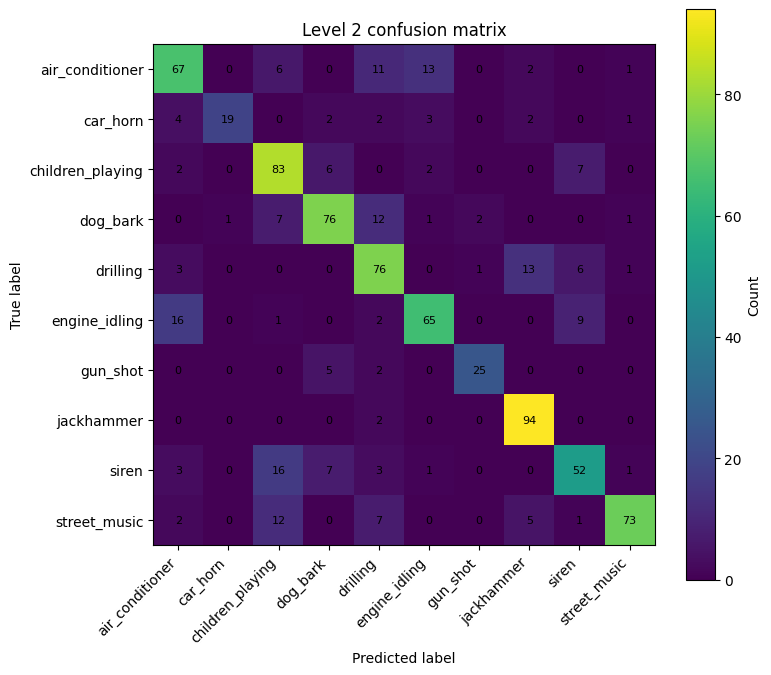


Level 2 confusion matrix metrics
--------------------------------
Accuracy:          0.7527
Macro precision:   0.7843
Macro recall:      0.7412
Macro specificity: 0.9721
Macro F1-score:    0.7540


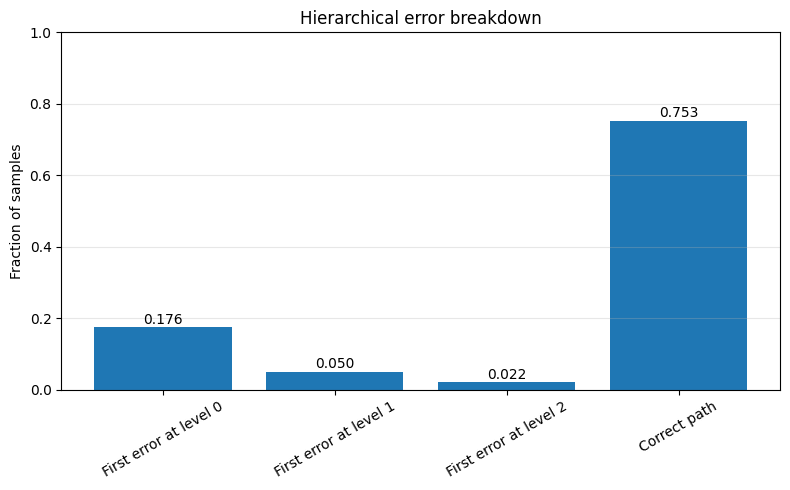

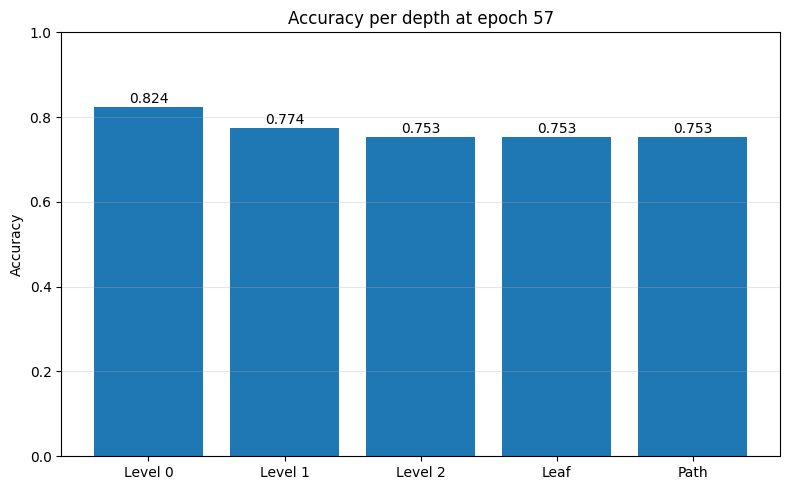

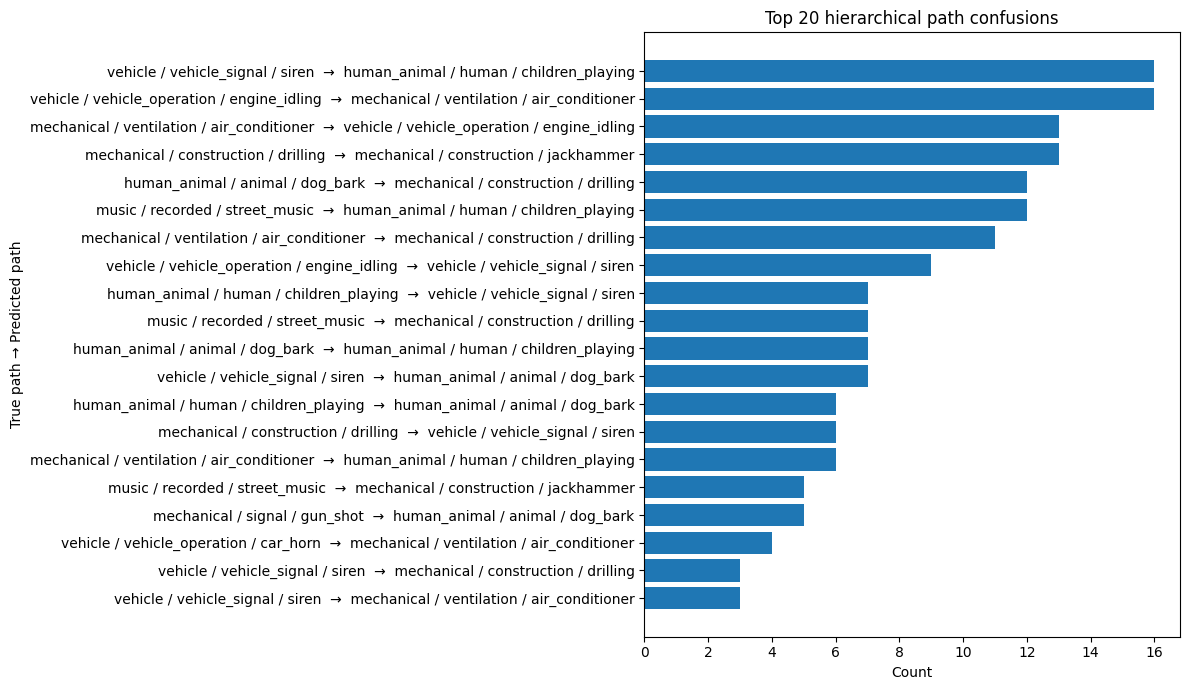

,true_path,pred_path,count
10,vehicle / vehicle_signal / siren,human_animal / human / children_playing,16
11,vehicle / vehicle_operation / engine_idling,mechanical / ventilation / air_conditioner,16
13,mechanical / ventilation / air_conditioner,vehicle / vehicle_operation / engine_idling,13
12,mechanical / construction / drilling,mechanical / construction / jackhammer,13
14,human_animal / animal / dog_bark,mechanical / construction / drilling,12
15,music / recorded / street_music,human_animal / human / children_playing,12
16,mechanical / ventilation / air_conditioner,mechanical / construction / drilling,11
17,vehicle / vehicle_operation / engine_idling,vehicle / vehicle_signal / siren,9
18,human_animal / human / children_playing,vehicle / vehicle_signal / siren,7
19,music / recorded / street_music,mechanical / construction / drilling,7


In [16]:
best_epoch = choose_best_epoch(metrics, metric="val_leaf_acc")
print(f"best epoch: {best_epoch}")
epoch_preds = filter_predictions_by_epoch(preds, best_epoch)

plot_leaf_confusion_matrix(epoch_preds, index_dict=hierarchy_index_dict)
plot_all_level_confusion_matrices(epoch_preds, index_dict=hierarchy_index_dict)

plot_hierarchical_error_breakdown(epoch_preds)
plot_accuracy_per_depth(metrics=metrics, epoch=best_epoch)
plot_top_hierarchical_confusions(epoch_preds, index_dict=hierarchy_index_dict)